In [1]:
!pip install transformers datasets rouge_score sentencepiece nltk scikit-learn -q

import numpy as np
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import sent_tokenize
from datasets import load_dataset
from rouge_score import rouge_scorer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import BartTokenizer, BartForConditionalGeneration
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Load vanilla BART
vanilla_tokenizer = BartTokenizer.from_pretrained("/content/drive/MyDrive/bart_final")
vanilla_model = BartForConditionalGeneration.from_pretrained("/content/drive/MyDrive/bart_final").to("cuda")

# Load oracle BART
oracle_tokenizer = BartTokenizer.from_pretrained("/content/drive/MyDrive/oracle_bart_v2")
oracle_model = BartForConditionalGeneration.from_pretrained("/content/drive/MyDrive/oracle_bart_v2").to("cuda")

print("Both models loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/512 [00:01<?, ?it/s]

Both models loaded.


In [4]:
dataset = load_dataset("cnn_dailymail", "3.0.0")
test_data = dataset["test"].select(range(100))  # 100 is enough for all analysis

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

In [5]:
oracle_scorer_obj = rouge_scorer.RougeScorer(['rouge2'], use_stemmer=True)

def get_oracle_test(article, n=3):
    sents = sent_tokenize(article)
    if len(sents) <= n:
        return " ".join(sents)
    vect = TfidfVectorizer(stop_words="english")
    X = vect.fit_transform([article] + sents)
    scores = cosine_similarity(X[0], X[1:])[0]
    top_idx = sorted(np.argsort(scores)[-n:])
    return " ".join([sents[i] for i in top_idx])

In [6]:
# Identical settings for fair comparison — this is important
GEN_KWARGS = dict(
    num_beams=4,
    no_repeat_ngram_size=3,
    length_penalty=2.0,
    max_length=128,
    min_length=30,
    early_stopping=True
)

def summarize_vanilla(article):
    inputs = vanilla_tokenizer(
        article, return_tensors="pt",
        truncation=True, max_length=768
    ).to("cuda")
    ids = vanilla_model.generate(inputs["input_ids"], **GEN_KWARGS)
    return vanilla_tokenizer.decode(ids[0], skip_special_tokens=True)

def summarize_oracle(article):
    oracle = get_oracle_test(article, n=3)
    guided = oracle + " </s> " + article
    inputs = oracle_tokenizer(
        guided, return_tensors="pt",
        truncation=True, max_length=1024
    ).to("cuda")
    ids = oracle_model.generate(inputs["input_ids"], **GEN_KWARGS)
    return oracle_tokenizer.decode(ids[0], skip_special_tokens=True)

In [7]:
print("Generating summaries for 100 test articles...")

vanilla_summaries = []
oracle_summaries = []
references = []
articles = []

for i in range(100):
    article = test_data[i]["article"]
    ref = test_data[i]["highlights"]

    vanilla_summaries.append(summarize_vanilla(article))
    oracle_summaries.append(summarize_oracle(article))
    references.append(ref)
    articles.append(article)

    if (i+1) % 10 == 0:
        print(f"Done {i+1}/100")

print("All summaries generated.")

Generating summaries for 100 test articles...
Done 10/100
Done 20/100
Done 30/100
Done 40/100
Done 50/100
Done 60/100
Done 70/100
Done 80/100
Done 90/100
Done 100/100
All summaries generated.


In [8]:
eval_scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

v_r1, v_r2, v_rl = [], [], []
o_r1, o_r2, o_rl = [], [], []

for i in range(100):
    vs = eval_scorer.score(references[i], vanilla_summaries[i])
    os_ = eval_scorer.score(references[i], oracle_summaries[i])

    v_r1.append(vs["rouge1"].fmeasure)
    v_r2.append(vs["rouge2"].fmeasure)
    v_rl.append(vs["rougeL"].fmeasure)

    o_r1.append(os_["rouge1"].fmeasure)
    o_r2.append(os_["rouge2"].fmeasure)
    o_rl.append(os_["rougeL"].fmeasure)

print("=== ROUGE RESULTS (fair comparison, identical generation settings) ===")
print(f"Vanilla BART  | R1: {np.mean(v_r1):.4f} | R2: {np.mean(v_r2):.4f} | RL: {np.mean(v_rl):.4f}")
print(f"Oracle BART   | R1: {np.mean(o_r1):.4f} | R2: {np.mean(o_r2):.4f} | RL: {np.mean(o_rl):.4f}")

=== ROUGE RESULTS (fair comparison, identical generation settings) ===
Vanilla BART  | R1: 0.3557 | R2: 0.1579 | RL: 0.2640
Oracle BART   | R1: 0.3600 | R2: 0.1517 | RL: 0.2521


In [9]:
sent_scorer = rouge_scorer.RougeScorer(['rouge2'], use_stemmer=True)

def avg_source_position(article, summary):
    art_sents = sent_tokenize(article)
    sum_sents = sent_tokenize(summary)
    if not art_sents or not sum_sents:
        return 0.5
    positions = []
    for s in sum_sents:
        best_score, best_pos = -1, 0
        for i, a in enumerate(art_sents):
            score = sent_scorer.score(s, a)["rouge2"].fmeasure
            if score > best_score:
                best_score, best_pos = score, i
        positions.append(best_pos / max(len(art_sents)-1, 1))
    return np.mean(positions)

vanilla_positions = [avg_source_position(articles[i], vanilla_summaries[i]) for i in range(100)]
oracle_positions  = [avg_source_position(articles[i], oracle_summaries[i])  for i in range(100)]

print("=== LEAD BIAS ANALYSIS ===")
print(f"Vanilla BART avg source position: {np.mean(vanilla_positions):.4f}  (0=start, 1=end)")
print(f"Oracle BART  avg source position: {np.mean(oracle_positions):.4f}")
print()
print("Interpretation: lower number = stronger lead bias (model copies from article start)")
print("Higher oracle position = oracle guidance pushed model to look deeper into article")

=== LEAD BIAS ANALYSIS ===
Vanilla BART avg source position: 0.2832  (0=start, 1=end)
Oracle BART  avg source position: 0.3071

Interpretation: lower number = stronger lead bias (model copies from article start)
Higher oracle position = oracle guidance pushed model to look deeper into article


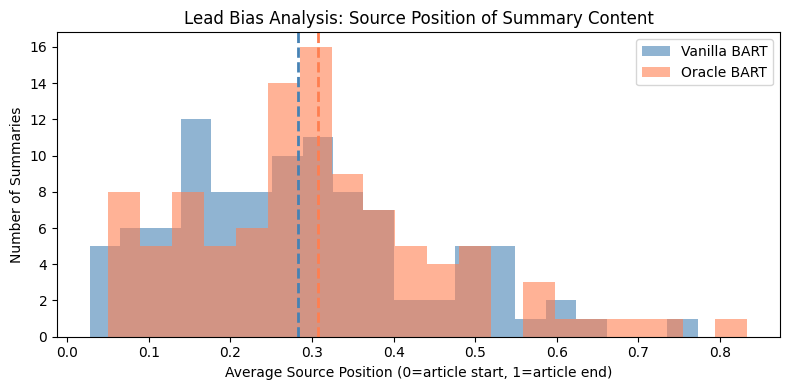

Saved as lead_bias.png


In [10]:
plt.figure(figsize=(8, 4))
plt.hist(vanilla_positions, bins=20, alpha=0.6, label='Vanilla BART', color='steelblue')
plt.hist(oracle_positions,  bins=20, alpha=0.6, label='Oracle BART',  color='coral')
plt.axvline(np.mean(vanilla_positions), color='steelblue', linestyle='--', linewidth=2)
plt.axvline(np.mean(oracle_positions),  color='coral',     linestyle='--', linewidth=2)
plt.xlabel("Average Source Position (0=article start, 1=article end)")
plt.ylabel("Number of Summaries")
plt.title("Lead Bias Analysis: Source Position of Summary Content")
plt.legend()
plt.tight_layout()
plt.savefig("lead_bias.png", dpi=150)
plt.show()
print("Saved as lead_bias.png")

In [11]:
abs_scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=False)

def novelty_score(summary, article):
    # Low precision = summary uses words NOT in article = more abstractive
    return 1 - abs_scorer.score(article, summary)["rouge1"].precision

vanilla_novelty = [novelty_score(vanilla_summaries[i], articles[i]) for i in range(100)]
oracle_novelty  = [novelty_score(oracle_summaries[i],  articles[i]) for i in range(100)]

print("=== ABSTRACTIVENESS ANALYSIS ===")
print(f"Vanilla BART abstractiveness: {np.mean(vanilla_novelty):.4f}")
print(f"Oracle BART  abstractiveness: {np.mean(oracle_novelty):.4f}")
print("Higher = more abstractive (generating novel words vs copying from article)")

=== ABSTRACTIVENESS ANALYSIS ===
Vanilla BART abstractiveness: 0.0369
Oracle BART  abstractiveness: 0.0454
Higher = more abstractive (generating novel words vs copying from article)


In [12]:
# Find articles where oracle sentences come from deep in the article
# These are the best cases to show your professor

deep_cases = []
for i in range(100):
    art_sents = sent_tokenize(articles[i])
    oracle_text = get_oracle_test(articles[i], n=3)
    oracle_sents = sent_tokenize(oracle_text)

    # find where oracle sentences appear in original article
    positions = []
    for os in oracle_sents:
        best_pos = 0
        best_score = -1
        for j, a in enumerate(art_sents):
            sc = sent_scorer.score(os, a)["rouge2"].fmeasure
            if sc > best_score:
                best_score, best_pos = sc, j
        positions.append(best_pos)

    avg_pos = np.mean(positions) if positions else 0
    if avg_pos > 4:  # oracle content from sentence 5+ = non-lead article
        deep_cases.append((i, avg_pos))

deep_cases.sort(key=lambda x: -x[1])  # sort by deepest oracle
print(f"Found {len(deep_cases)} non-lead articles. Showing top 5:\n")

for rank, (i, pos) in enumerate(deep_cases[:5]):
    print(f"{'='*60}")
    print(f"EXAMPLE {rank+1} (oracle avg position: sentence {pos:.1f})")
    print(f"\nARTICLE START:\n{articles[i][:400]}...")
    print(f"\nORACLE SENTENCES:\n{get_oracle_test(articles[i])}")
    print(f"\nVANILLA BART:\n{vanilla_summaries[i]}")
    print(f"\nORACLE BART:\n{oracle_summaries[i]}")
    print(f"\nREFERENCE:\n{references[i]}")
    print()

Found 71 non-lead articles. Showing top 5:

EXAMPLE 1 (oracle avg position: sentence 73.3)

ARTICLE START:
(CNN)Mark Ronson's "Uptown Funk!," featuring Bruno Mars, is the longest-leading Billboard Hot 100 of the 2010s, ruling the chart for a 13th week. It's also just the 10th single in the Hot 100's entire history to spend at least 13 weeks at No. 1. Plus, newcomer Natalie La Rose reaches the top 10 with her debut hit "Somebody," featuring Jeremih. As we do each Wednesday, let's run down all the songs ...

ORACLE SENTENCES:
"Funk," thus, leads the Hot 100 and its three main component charts (Digital Songs, Radio Songs and Streaming Songs) simultaneously for a record-extending ninth week (nonconsecutively). 5 on Radio Songs (118 million, up 8 percent) and Streaming Songs (9 million, up 9 percent). The Dutch singer's debut hit lifts 10-8 on Radio Songs (73 million, up 9 percent); backtracks 13-14 on Digital Songs, but with a 7 percent gain to 68,000; and zooms 31-19 on Streaming Songs (4